In [1]:
import math
import random
import shutil
import time
import urllib.error
import urllib.request
import zipfile
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import torch.nn.functional as F
import yaml
from PIL import Image, ImageDraw
from torch.utils.data import DataLoader, Dataset
from torchvision.ops import batched_nms, box_iou
from torchvision.transforms import functional as TF
from tqdm.auto import tqdm

# =========================================================
# CẤU HÌNH HỆ THỐNG & ĐƯỜNG DẪN DATASET
# =========================================================
IN_COLAB = "COLAB_RELEASE_TAG" in __import__("os").environ
IN_KAGGLE = Path("/kaggle/working").exists()

if IN_COLAB:
    try:
        from google.colab import drive

        drive.mount("/content/drive")
        DATA_ROOT = Path("/content/drive/MyDrive/datasets/road_damage_pcm")
    except (ImportError, RuntimeError):
        DATA_ROOT = Path("/content/data/road_damage_pcm")
elif IN_KAGGLE:
    DATA_ROOT = Path("/kaggle/working/datasets/road_damage_pcm")
else:
    DATA_ROOT = Path("./data/road_damage_pcm")

IMAGE_SIZE = 416  # Kích thước ảnh chuẩn của YOLOv3 (chia hết cho 32)
BATCH_SIZE = 8
NUM_CLASSES = 3
CLASS_NAMES = ["Pothole", "Crack", "Manhole"]
NUM_EPOCHS = 25
LEARNING_RATE = 1e-3
WEIGHT_DECAY = 5e-4
NUM_WORKERS = 0
SEED = 42
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
AUTO_DOWNLOAD_DATASET = True


def set_seed(seed=SEED):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False


set_seed(SEED)
print(f"Device: {DEVICE}")
print(
    f"Data root: {DATA_ROOT.resolve() if not IN_COLAB and not IN_KAGGLE else DATA_ROOT}"
)

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Device: cuda
Data root: /content/drive/MyDrive/datasets/road_damage_pcm


In [2]:
# =========================================================
# TẢI VÀ CHIA TẬP DỮ LIỆU TRAIN / VALID (80/20)
# =========================================================
DATASET_URL = (
    "https://www.kaggle.com/api/v1/datasets/download/"
    "lorenzoarcioni/road-damage-dataset-potholes-cracks-and-manholes"
)
DATASET_ARCHIVE = DATA_ROOT.parent / "road_damage_pcm.zip"


def prepare_road_damage_dataset(data_root=DATA_ROOT):
    """Tải, chia 80/20 và đưa dataset về cấu trúc YOLO train/valid."""
    ready_file = data_root / ".ready"
    if ready_file.exists():
        print(f"Dataset đã sẵn sàng tại: {data_root}")
        return

    DATASET_ARCHIVE.parent.mkdir(parents=True, exist_ok=True)
    if not DATASET_ARCHIVE.exists() or not zipfile.is_zipfile(DATASET_ARCHIVE):
        print("Đang tải Road Damage Dataset (~195 MB)...")
        urllib.request.urlretrieve(DATASET_URL, DATASET_ARCHIVE)

    image_prefix = "data/images/"
    label_prefix = "data/labels-YOLO/"
    image_exts = {".jpg", ".jpeg", ".png", ".bmp", ".webp"}

    with zipfile.ZipFile(DATASET_ARCHIVE) as archive:
        names = archive.namelist()
        labels = set(name for name in names if name.startswith(label_prefix))
        pairs = []
        for image_name in names:
            if (
                not image_name.startswith(image_prefix)
                or Path(image_name).suffix.lower() not in image_exts
            ):
                continue
            label_name = f"{label_prefix}{Path(image_name).stem}.txt"
            if label_name in labels:
                pairs.append((image_name, label_name))

        random.Random(SEED).shuffle(pairs)
        split_index = int(0.8 * len(pairs))
        for index, (image_name, label_name) in enumerate(
            tqdm(pairs, desc="Chuẩn hóa dataset")
        ):
            split = "train" if index < split_index else "valid"
            for member, folder in (
                (image_name, "images"),
                (label_name, "labels"),
            ):
                destination = data_root / split / folder / Path(member).name
                destination.parent.mkdir(parents=True, exist_ok=True)
                with (
                    archive.open(member) as source,
                    destination.open("wb") as target,
                ):
                    shutil.copyfileobj(source, target)

    data_yaml = {
        "path": str(data_root.resolve()),
        "train": "train/images",
        "val": "valid/images",
        "names": CLASS_NAMES,
    }
    with (data_root / "data.yaml").open("w", encoding="utf-8") as file:
        yaml.safe_dump(data_yaml, file, sort_keys=False, allow_unicode=True)
    ready_file.write_text(str(len(pairs)), encoding="utf-8")
    print(
        f"Hoàn tất: {split_index} train | {len(pairs) - split_index} validation"
    )


if AUTO_DOWNLOAD_DATASET:
    try:
        prepare_road_damage_dataset()
        DATA_AVAILABLE = True
    except (OSError, urllib.error.URLError, zipfile.BadZipFile) as error:
        print("Không thể tải dataset:", error)
        DATA_AVAILABLE = False

Dataset đã sẵn sàng tại: /content/drive/MyDrive/datasets/road_damage_pcm


In [3]:
# =========================================================
# K-MEANS CLUSTERING (IOU DISTANCE METRIC)
# =========================================================
def box_iou_wh(box1, box2):
    """Tính IoU giữa các box theo width và height (tự động xử lý cả Tensor lẫn ndarray)."""
    if isinstance(box1, np.ndarray) and isinstance(box2, np.ndarray):
        w1, h1 = box1[:, 0], box1[:, 1]
        w2, h2 = box2[:, 0], box2[:, 1]
        inter_area = np.minimum(w1[:, None], w2[None, :]) * np.minimum(
            h1[:, None], h2[None, :]
        )
        union_area = (w1 * h1)[:, None] + (w2 * h2)[None, :] - inter_area
        return inter_area / (union_area + 1e-16)
    else:
        if not isinstance(box1, torch.Tensor):
            box1 = torch.tensor(box1, dtype=torch.float32)
        if not isinstance(box2, torch.Tensor):
            box2 = torch.tensor(box2, dtype=torch.float32)
        w1, h1 = box1[:, 0], box1[:, 1]
        w2, h2 = box2[:, 0], box2[:, 1]
        inter_area = torch.minimum(w1[:, None], w2[None, :]) * torch.minimum(
            h1[:, None], h2[None, :]
        )
        union_area = (w1 * h1)[:, None] + (w2 * h2)[None, :] - inter_area
        return inter_area / (union_area + 1e-16)


def compute_kmeans_anchors(boxes_wh, num_anchors=9, max_iters=300):
    """Tìm 9 anchor box tối ưu bằng K-Means với khoảng cách d = 1 - IoU."""
    num_boxes = boxes_wh.shape[0]
    np.random.seed(SEED)
    centroids = boxes_wh[
        np.random.choice(num_boxes, num_anchors, replace=False)
    ]

    for _ in range(max_iters):
        distances = 1.0 - box_iou_wh(boxes_wh, centroids)
        assignments = np.argmin(distances, axis=1)

        new_centroids = np.zeros_like(centroids)
        for cluster_id in range(num_anchors):
            members = boxes_wh[assignments == cluster_id]
            if len(members) > 0:
                new_centroids[cluster_id] = np.median(members, axis=0)
            else:
                new_centroids[cluster_id] = boxes_wh[
                    np.random.choice(num_boxes)
                ]

        if np.allclose(centroids, new_centroids, atol=1e-4):
            break
        centroids = new_centroids

    # Sắp xếp diện tích tăng dần (từ vật thể nhỏ đến vật thể lớn)
    areas = centroids[:, 0] * centroids[:, 1]
    return centroids[np.argsort(areas)]


# Trích xuất bounding boxes từ tập train để phân cụm
def get_dataset_anchors(data_root=DATA_ROOT, image_size=IMAGE_SIZE):
    train_labels = list((Path(data_root) / "train" / "labels").glob("*.txt"))
    all_wh = []
    for lbl in train_labels:
        for line in lbl.read_text().splitlines():
            if line.strip():
                _, _, _, w, h = map(float, line.split())
                all_wh.append([w * image_size, h * image_size])

    if len(all_wh) >= 9:
        clustered = compute_kmeans_anchors(np.array(all_wh), num_anchors=9)
        anchors = [
            [tuple(clustered[i]) for i in range(0, 3)],  # Small (52x52)
            [tuple(clustered[i]) for i in range(3, 6)],  # Medium (26x26)
            [tuple(clustered[i]) for i in range(6, 9)],  # Large (13x13)
        ]
    else:
        # Fallback anchor boxes chuẩn của YOLOv3
        anchors = [
            [(10, 13), (16, 30), (33, 23)],
            [(30, 61), (62, 45), (59, 119)],
            [(116, 90), (156, 198), (373, 326)],
        ]
    return anchors


if DATA_AVAILABLE:
    ANCHORS = get_dataset_anchors(DATA_ROOT, IMAGE_SIZE)
    print("9 K-Means Anchors được phân cụm thành công:")
    for scale_idx, scale_name in enumerate(["52x52", "26x26", "13x13"]):
        print(f"Scale {scale_name}: {ANCHORS[scale_idx]}")
else:
    ANCHORS = [
        [(10, 13), (16, 30), (33, 23)],
        [(30, 61), (62, 45), (59, 119)],
        [(116, 90), (156, 198), (373, 326)],
    ]

9 K-Means Anchors được phân cụm thành công:
Scale 52x52: [(np.float64(17.549792), np.float64(13.866528)), (np.float64(22.749792), np.float64(23.111296)), (np.float64(32.5), np.float64(18.488704))]
Scale 26x26: [(np.float64(29.9), np.float64(38.133472)), (np.float64(44.849792), np.float64(26.577824)), (np.float64(61.1), np.float64(40.444352))]
Scale 13x13: [(np.float64(42.899584), np.float64(63.555648)), (np.float64(79.950208), np.float64(75.111296)), (np.float64(163.150208), np.float64(116.711296))]


In [4]:
class YOLODetectionDataset(Dataset):

    def __init__(self, data_root, split, image_size, anchors):
        self.image_dir = Path(data_root) / split / "images"
        self.label_dir = Path(data_root) / split / "labels"
        self.image_size = image_size
        self.image_paths = sorted(
            [
                p
                for p in self.image_dir.iterdir()
                if p.suffix.lower() in [".jpg", ".png", ".jpeg", ".bmp", ".webp"]
            ]
        )
        self.anchors = torch.tensor(
            anchors[0] + anchors[1] + anchors[2], dtype=torch.float32
        )
        self.num_anchors_per_scale = 3
        # Thứ tự scale: 13x13 (stride 32), 26x26 (stride 16), 52x52 (stride 8)
        self.grid_sizes = [image_size // 32, image_size // 16, image_size // 8]

    def __len__(self):
        return len(self.image_paths)

    def __getitem__(self, index):
        image_path = self.image_paths[index]
        image = Image.open(image_path).convert("RGB")
        image = TF.to_tensor(
            TF.resize(image, [self.image_size, self.image_size], antialias=True)
        )

        label_path = self.label_dir / f"{image_path.stem}.txt"
        boxes = []
        if label_path.exists():
            for line in label_path.read_text().splitlines():
                if line.strip():
                    cls, x, y, w, h = map(float, line.split())
                    boxes.append([x, y, w, h, int(cls)])

        boxes = torch.tensor(boxes, dtype=torch.float32)
        targets = [
            torch.zeros((self.num_anchors_per_scale, S, S, 6))
            for S in self.grid_sizes
        ]

        if len(boxes) > 0:
            # Tính IoU giữa các bounding box và 9 anchors
            iou_anchors = box_iou_wh(
                boxes[:, 2:4] * self.image_size, self.anchors
            )

            # Sử dụng torch.argsort với descending=True để sắp xếp giảm dần (không dùng [:, ::-1])
            anchor_indices = torch.argsort(
                iou_anchors, dim=1, descending=True
            )

            for box_idx, box in enumerate(boxes):
                x, y, width, height, class_label = box
                has_anchor = [False, False, False]

                for a_idx in anchor_indices[box_idx]:
                    # Map: Small (0..2) -> Scale 52x52 (idx 2) | Large (6..8) -> Scale 13x13 (idx 0)
                    scale_idx = 2 - (
                        a_idx.item() // self.num_anchors_per_scale
                    )
                    anchor_on_scale = a_idx.item() % self.num_anchors_per_scale
                    S = self.grid_sizes[scale_idx]
                    i, j = int(S * y.item()), int(S * x.item())
                    anchor_taken = targets[scale_idx][anchor_on_scale, i, j, 4]

                    if not anchor_taken and not has_anchor[scale_idx]:
                        targets[scale_idx][anchor_on_scale, i, j, 4] = 1.0
                        x_cell = S * x.item() - j
                        y_cell = S * y.item() - i
                        w_cell = width.item() * S
                        h_cell = height.item() * S
                        targets[scale_idx][anchor_on_scale, i, j, 0:4] = (
                            torch.tensor([x_cell, y_cell, w_cell, h_cell])
                        )
                        targets[scale_idx][anchor_on_scale, i, j, 5] = (
                            class_label.long()
                        )
                        has_anchor[scale_idx] = True

        raw_target = {
            "boxes": (
                boxes[:, :4]
                if len(boxes) > 0
                else torch.zeros((0, 4), dtype=torch.float32)
            ),
            "labels": (
                boxes[:, 4].long()
                if len(boxes) > 0
                else torch.zeros((0,), dtype=torch.long)
            ),
        }
        return image, tuple(targets), raw_target

def yolo_collate_fn(batch):
    images = [item[0] for item in batch]
    targets = [
        [item[1][0] for item in batch],
        [item[1][1] for item in batch],
        [item[1][2] for item in batch],
    ]
    raw_targets = [item[2] for item in batch]

    # Stack images
    images = torch.stack(images, 0)

    # Stack targets for each scale
    targets_0 = torch.stack(targets[0], 0)
    targets_1 = torch.stack(targets[1], 0)
    targets_2 = torch.stack(targets[2], 0)

    # For raw_targets, which can have varying number of boxes, return as a list of dicts
    return images, (targets_0, targets_1, targets_2), raw_targets

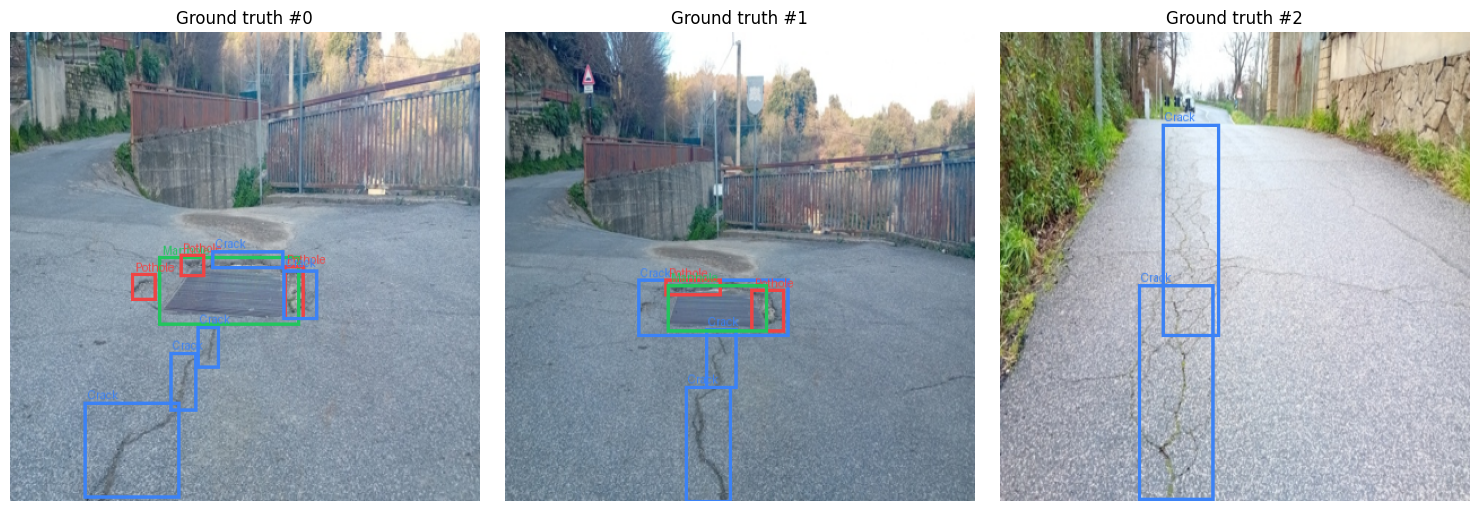

In [5]:
# =========================================================
# VISUALIZATION DATASET
# =========================================================
BOX_COLORS = ["#ef4444", "#3b82f6", "#22c55e", "#f59e0b", "#a855f7"]


def xywhn_to_xyxy(boxes, image_size):
    if boxes.numel() == 0:
        return boxes.reshape(0, 4)
    x, y, w, h = boxes.unbind(-1)
    return torch.stack(
        [
            (x - w / 2) * image_size,
            (y - h / 2) * image_size,
            (x + w / 2) * image_size,
            (y + h / 2) * image_size,
        ],
        dim=-1,
    )


def draw_boxes(image, boxes, labels, scores=None, class_names=CLASS_NAMES):
    canvas = TF.to_pil_image(image.cpu().clamp(0, 1))
    draw = ImageDraw.Draw(canvas)
    for index, (box, label) in enumerate(zip(boxes, labels)):
        color = BOX_COLORS[int(label) % len(BOX_COLORS)]
        x1, y1, x2, y2 = [float(value) for value in box]
        draw.rectangle((x1, y1, x2, y2), outline=color, width=3)
        text = class_names[int(label)]
        if scores is not None:
            text += f" {float(scores[index]):.2f}"
        draw.text((x1 + 3, max(0, y1 - 12)), text, fill=color)
    return canvas


def show_dataset_samples(dataset, count=3):
    count = min(count, len(dataset))
    fig, axes = plt.subplots(1, count, figsize=(5 * count, 5), squeeze=False)
    for index in range(count):
        image, _, raw_target = dataset[index]
        boxes = xywhn_to_xyxy(raw_target["boxes"], image.shape[-1])
        axes[0, index].imshow(draw_boxes(image, boxes, raw_target["labels"]))
        axes[0, index].set_title(f"Ground truth #{index}")
        axes[0, index].axis("off")
    plt.tight_layout()
    plt.show()


if DATA_AVAILABLE:
    train_dataset = YOLODetectionDataset(
        DATA_ROOT, "train", IMAGE_SIZE, ANCHORS
    )
    val_dataset = YOLODetectionDataset(
        DATA_ROOT, "valid", IMAGE_SIZE, ANCHORS
    )
    train_loader = DataLoader(
        train_dataset,
        batch_size=BATCH_SIZE,
        shuffle=True,
        num_workers=NUM_WORKERS,
        pin_memory=True,
        collate_fn=yolo_collate_fn
    )
    val_loader = DataLoader(
        val_dataset,
        batch_size=BATCH_SIZE,
        shuffle=False,
        num_workers=NUM_WORKERS,
        pin_memory=True,
        collate_fn=yolo_collate_fn
    )
    show_dataset_samples(train_dataset)

In [6]:
# =========================================================
# CÁC KHỐI KIẾN TRÚC: CNNBlock & ResidualBlock
# =========================================================
class CNNBlock(nn.Module):

    def __init__(self, in_channels, out_channels, **kwargs):
        super().__init__()
        self.conv = nn.Conv2d(in_channels, out_channels, bias=False, **kwargs)
        self.bn = nn.BatchNorm2d(out_channels)
        self.leaky = nn.LeakyReLU(0.1, inplace=True)

    def forward(self, x):
        return self.leaky(self.bn(self.conv(x)))


class ResidualBlock(nn.Module):

    def __init__(self, channels, num_repeats=1):
        super().__init__()
        self.layers = nn.ModuleList()
        for _ in range(num_repeats):
            self.layers.append(
                nn.Sequential(
                    CNNBlock(channels, channels // 2, kernel_size=1),
                    CNNBlock(channels // 2, channels, kernel_size=3, padding=1),
                )
            )

    def forward(self, x):
        for layer in self.layers:
            x = x + layer(x)
        return x


# =========================================================
# BACKBONE: DARKNET-53
# =========================================================
class Darknet53(nn.Module):

    def __init__(self, in_channels=3):
        super().__init__()
        self.stem = CNNBlock(
            in_channels, 32, kernel_size=3, stride=1, padding=1
        )
        self.conv1 = CNNBlock(32, 64, kernel_size=3, stride=2, padding=1)
        self.res1 = ResidualBlock(64, num_repeats=1)

        self.conv2 = CNNBlock(64, 128, kernel_size=3, stride=2, padding=1)
        self.res2 = ResidualBlock(128, num_repeats=2)

        self.conv3 = CNNBlock(128, 256, kernel_size=3, stride=2, padding=1)
        self.res3 = ResidualBlock(256, num_repeats=8)  # Route 52x52

        self.conv4 = CNNBlock(256, 512, kernel_size=3, stride=2, padding=1)
        self.res4 = ResidualBlock(512, num_repeats=8)  # Route 26x26

        self.conv5 = CNNBlock(512, 1024, kernel_size=3, stride=2, padding=1)
        self.res5 = ResidualBlock(1024, num_repeats=4)  # Route 13x13

    def forward(self, x):
        x = self.stem(x)
        x = self.res1(self.conv1(x))
        x = self.res2(self.conv2(x))
        route_52 = self.res3(self.conv3(x))
        route_26 = self.res4(self.conv4(route_52))
        route_13 = self.res5(self.conv5(route_26))
        return route_52, route_26, route_13


# =========================================================
# MÔ HÌNH YOLOV3 TOÀN PHẦN (BACKBONE + FPN NECK + HEAD)
# =========================================================
class YOLOv3(nn.Module):

    def __init__(self, num_classes=NUM_CLASSES):
        super().__init__()
        self.num_classes = num_classes
        self.backbone = Darknet53()

        out_pred_dim = 3 * (5 + num_classes)

        # Scale 13x13 (Large Objects)
        self.neck13 = nn.Sequential(
            CNNBlock(1024, 512, kernel_size=1),
            CNNBlock(512, 1024, kernel_size=3, padding=1),
            CNNBlock(1024, 512, kernel_size=1),
            CNNBlock(512, 1024, kernel_size=3, padding=1),
            CNNBlock(1024, 512, kernel_size=1),
        )
        self.head13 = nn.Sequential(
            CNNBlock(512, 1024, kernel_size=3, padding=1),
            nn.Conv2d(1024, out_pred_dim, kernel_size=1),
        )

        # Scale 26x26 (Medium Objects)
        self.up13_to_26 = nn.Sequential(
            CNNBlock(512, 256, kernel_size=1),
            nn.Upsample(scale_factor=2, mode="nearest"),
        )
        self.neck26 = nn.Sequential(
            CNNBlock(512 + 256, 256, kernel_size=1),
            CNNBlock(256, 512, kernel_size=3, padding=1),
            CNNBlock(512, 256, kernel_size=1),
            CNNBlock(256, 512, kernel_size=3, padding=1),
            CNNBlock(512, 256, kernel_size=1),
        )
        self.head26 = nn.Sequential(
            CNNBlock(256, 512, kernel_size=3, padding=1),
            nn.Conv2d(512, out_pred_dim, kernel_size=1),
        )

        # Scale 52x52 (Small Objects)
        self.up26_to_52 = nn.Sequential(
            CNNBlock(256, 128, kernel_size=1),
            nn.Upsample(scale_factor=2, mode="nearest"),
        )
        self.neck52 = nn.Sequential(
            CNNBlock(256 + 128, 128, kernel_size=1),
            CNNBlock(128, 256, kernel_size=3, padding=1),
            CNNBlock(256, 128, kernel_size=1),
            CNNBlock(128, 256, kernel_size=3, padding=1),
            CNNBlock(256, 128, kernel_size=1),
        )
        self.head52 = nn.Sequential(
            CNNBlock(128, 256, kernel_size=3, padding=1),
            nn.Conv2d(256, out_pred_dim, kernel_size=1),
        )

    def forward(self, x):
        route_52, route_26, route_13 = self.backbone(x)

        # 13x13
        x13_neck = self.neck13(route_13)
        out13 = self.head13(x13_neck)

        # 26x26
        x13_up = self.up13_to_26(x13_neck)
        x26_cat = torch.cat([x13_up, route_26], dim=1)
        x26_neck = self.neck26(x26_cat)
        out26 = self.head26(x26_neck)

        # 52x52
        x26_up = self.up26_to_52(x26_neck)
        x52_cat = torch.cat([x26_up, route_52], dim=1)
        x52_neck = self.neck52(x52_cat)
        out52 = self.head52(x52_neck)

        return out13, out26, out52

In [7]:
# =========================================================
# QUICK SHAPE TEST
# =========================================================
set_seed(SEED)
test_model = YOLOv3(num_classes=NUM_CLASSES).to(DEVICE)
test_model.eval()

x = torch.randn(2, 3, IMAGE_SIZE, IMAGE_SIZE, device=DEVICE)
with torch.no_grad():
    out13, out26, out52 = test_model(x)

expected_channels = 3 * (5 + NUM_CLASSES)
print(
    f"Output Scale 1 (13x13): {out13.shape} (Expected: [2, {expected_channels}, 13, 13])"
)
print(
    f"Output Scale 2 (26x26): {out26.shape} (Expected: [2, {expected_channels}, 26, 26])"
)
print(
    f"Output Scale 3 (52x52): {out52.shape} (Expected: [2, {expected_channels}, 52, 52])"
)

assert out13.shape == (2, expected_channels, 13, 13)
assert out26.shape == (2, expected_channels, 26, 26)
assert out52.shape == (2, expected_channels, 52, 52)
print(">> SHAPE TEST THÀNH CÔNG!")

Output Scale 1 (13x13): torch.Size([2, 24, 13, 13]) (Expected: [2, 24, 13, 13])
Output Scale 2 (26x26): torch.Size([2, 24, 26, 26]) (Expected: [2, 24, 26, 26])
Output Scale 3 (52x52): torch.Size([2, 24, 52, 52]) (Expected: [2, 24, 52, 52])
>> SHAPE TEST THÀNH CÔNG!


In [12]:
# =========================================================
# HÀM LOSS YOLOV3 VỚI BCE ĐỘC LẬP TỪNG CLASS
# =========================================================
def intersection_over_union(boxes_preds, boxes_labels):
    box1_x1 = boxes_preds[..., 0:1] - boxes_preds[..., 2:3] / 2
    box1_y1 = boxes_preds[..., 1:2] - boxes_preds[..., 3:4] / 2
    box1_x2 = boxes_preds[..., 0:1] + boxes_preds[..., 2:3] / 2
    box1_y2 = boxes_preds[..., 1:2] + boxes_preds[..., 3:4] / 2

    box2_x1 = boxes_labels[..., 0:1] - boxes_labels[..., 2:3] / 2
    box2_y1 = boxes_labels[..., 1:2] - boxes_labels[..., 3:4] / 2
    box2_x2 = boxes_labels[..., 0:1] + boxes_labels[..., 2:3] / 2
    box2_y2 = boxes_labels[..., 1:2] + boxes_labels[..., 3:4] / 2

    x1 = torch.max(box1_x1, box2_x1)
    y1 = torch.max(box1_y1, box2_y1)
    x2 = torch.min(box1_x2, box2_x2)
    y2 = torch.min(box1_y2, box2_y2)

    intersection = (x2 - x1).clamp(0) * (y2 - y1).clamp(0)
    box1_area = (box1_x2 - box1_x1) * (box1_y2 - box1_y1)
    box2_area = (box2_x2 - box2_x1) * (box2_y2 - box2_y1)
    return intersection / (box1_area + box2_area - intersection + 1e-16)


class YOLOv3Loss(nn.Module):

    def __init__(self):
        super().__init__()
        self.mse = nn.MSELoss()
        self.bce = nn.BCEWithLogitsLoss()
        self.sigmoid = nn.Sigmoid()

        self.lambda_class = 1.0
        self.lambda_noobj = 0.5
        self.lambda_obj = 1.0
        self.lambda_box = 5.0
        self.num_classes = NUM_CLASSES # Store NUM_CLASSES for one-hot encoding

    def forward(self, predictions, target, anchors):
        obj = target[..., 4] == 1
        noobj = target[..., 4] == 0

        # 1. No Objectness Loss
        no_object_loss = self.bce(
            predictions[..., 4:5][noobj], target[..., 4:5][noobj]
        )

        # 2. Objectness & Box Loss
        anchors = anchors.reshape(1, 3, 1, 1, 2)
        box_preds = torch.cat(
            [
                self.sigmoid(predictions[..., 0:2]),
                torch.exp(predictions[..., 2:4]) * anchors,
            ],
            dim=-1,
        )
        ious = intersection_over_union(
            box_preds[obj], target[..., 0:4][obj]
        ).detach()
        object_loss = self.bce(
            predictions[..., 4:5][obj], ious * target[..., 4:5][obj]
        )

        predictions[..., 0:2] = self.sigmoid(predictions[..., 0:2])
        target[..., 2:4] = torch.log(1e-16 + target[..., 2:4] / anchors)
        box_loss = self.mse(predictions[..., 0:4][obj], target[..., 0:4][obj])

        # 3. Class Loss (Independent Binary Cross Entropy)
        # Convert target class labels to one-hot encoding
        class_labels_one_hot = F.one_hot(
            target[..., 5][obj].long(), num_classes=self.num_classes
        ).float()
        class_loss = self.bce(
            predictions[..., 5:][obj],
            class_labels_one_hot.to(predictions.device) # Ensure target is on the same device
        )

        total_loss = (
            self.lambda_box * box_loss
            + self.lambda_obj * object_loss
            + self.lambda_noobj * no_object_loss
            + self.lambda_class * class_loss
        )
        return total_loss, {
            "box_loss": box_loss.item(),
            "obj_loss": object_loss.item(),
            "noobj_loss": no_object_loss.item(),
            "class_loss": class_loss.item(),
        }

In [13]:
# =========================================================
# HUẤN LUYỆN MÔ HÌNH YOLOV3
# =========================================================
def train_epoch(model, loader, criterion, optimizer, scaled_anchors):
    model.train()
    total_loss = 0.0
    for images, targets, _ in tqdm(loader, leave=False):
        images = images.to(DEVICE)
        t13, t26, t52 = (
            targets[0].to(DEVICE),
            targets[1].to(DEVICE),
            targets[2].to(DEVICE),
        )

        optimizer.zero_grad(set_to_none=True)
        out13, out26, out52 = model(images)

        # Reshape [B, 3*(5+C), S, S] -> [B, 3, S, S, 5+C]
        out13 = (
            out13.view(
                images.shape[0], 3, 5 + NUM_CLASSES, 13, 13
            ).permute(0, 1, 3, 4, 2)
        )
        out26 = (
            out26.view(
                images.shape[0], 3, 5 + NUM_CLASSES, 26, 26
            ).permute(0, 1, 3, 4, 2)
        )
        out52 = (
            out52.view(
                images.shape[0], 3, 5 + NUM_CLASSES, 52, 52
            ).permute(0, 1, 3, 4, 2)
        )

        l13, _ = criterion(out13, t13, scaled_anchors[2])
        l26, _ = criterion(out26, t26, scaled_anchors[1])
        l52, _ = criterion(out52, t52, scaled_anchors[0])
        loss = l13 + l26 + l52

        loss.backward()
        optimizer.step()
        total_loss += loss.item() * images.shape[0]

    return total_loss / len(loader.dataset)


def validate_epoch(model, loader, criterion, scaled_anchors):
    model.eval()
    total_loss = 0.0
    with torch.no_grad():
        for images, targets, _ in tqdm(loader, leave=False):
            images = images.to(DEVICE)
            t13, t26, t52 = (
                targets[0].to(DEVICE),
                targets[1].to(DEVICE),
                targets[2].to(DEVICE),
            )
            out13, out26, out52 = model(images)

            out13 = (
                out13.view(
                    images.shape[0], 3, 5 + NUM_CLASSES, 13, 13
                ).permute(0, 1, 3, 4, 2)
            )
            out26 = (
                out26.view(
                    images.shape[0], 3, 5 + NUM_CLASSES, 26, 26
                ).permute(0, 1, 3, 4, 2)
            )
            out52 = (
                out52.view(
                    images.shape[0], 3, 5 + NUM_CLASSES, 52, 52
                ).permute(0, 1, 3, 4, 2)
            )

            l13, _ = criterion(out13, t13, scaled_anchors[2])
            l26, _ = criterion(out26, t26, scaled_anchors[1])
            l52, _ = criterion(out52, t52, scaled_anchors[0])
            total_loss += (l13 + l26 + l52).item() * images.shape[0]

    return total_loss / len(loader.dataset)


def train_model(model, train_loader, val_loader, num_epochs=NUM_EPOCHS):
    model = model.to(DEVICE)
    criterion = YOLOv3Loss()
    optimizer = torch.optim.Adam(
        model.parameters(), lr=LEARNING_RATE, weight_decay=WEIGHT_DECAY
    )
    scaled_anchors = (
        torch.tensor(ANCHORS, dtype=torch.float32, device=DEVICE)
        / torch.tensor([32, 16, 8], device=DEVICE).reshape(3, 1, 1)
    )

    history = []
    for epoch in range(1, num_epochs + 1):
        start = time.time()
        train_loss = train_epoch(
            model, train_loader, criterion, optimizer, scaled_anchors
        )
        val_loss = validate_epoch(
            model, val_loader, criterion, scaled_anchors
        )
        history.append(
            {"epoch": epoch, "train_loss": train_loss, "val_loss": val_loss}
        )
        print(
            f"Epoch {epoch:02d}/{num_epochs} | Train Loss: {train_loss:.4f} | Val Loss: {val_loss:.4f} | {time.time() - start:.1f}s"
        )

    return model, pd.DataFrame(history)


if DATA_AVAILABLE:
    set_seed(SEED)
    model = YOLOv3(NUM_CLASSES)
    model, history = train_model(model, train_loader, val_loader, NUM_EPOCHS)

  0%|          | 0/201 [00:00<?, ?it/s]

  0%|          | 0/51 [00:00<?, ?it/s]

Epoch 01/25 | Train Loss: 9.0458 | Val Loss: 6.6931 | 284.1s


  0%|          | 0/201 [00:00<?, ?it/s]

  0%|          | 0/51 [00:00<?, ?it/s]

...

  0%|          | 0/201 [00:00<?, ?it/s]

  0%|          | 0/51 [00:00<?, ?it/s]

Epoch 09/25 | Train Loss: 8.3913 | Val Loss: 6.6307 | 142.9s


  0%|          | 0/201 [00:00<?, ?it/s]

KeyboardInterrupt: 

In [14]:
# =========================================================
# GIẢI MÃ PREDICTION VÀ BATCHED NMS
# =========================================================
def decode_yolov3_outputs(outputs, anchors, image_size=IMAGE_SIZE):
    batch_size = outputs[0].shape[0]
    all_boxes = []
    for scale_idx, out in enumerate(outputs):
        S = out.shape[-1]
        stride = image_size // S
        out = (
            out.view(batch_size, 3, 5 + NUM_CLASSES, S, S)
            .permute(0, 1, 3, 4, 2)
            .contiguous()
        )

        anchor = (
            torch.tensor(
                anchors[2 - scale_idx], dtype=torch.float32, device=out.device
            )
            / stride
        )
        anchor = anchor.reshape(1, 3, 1, 1, 2)

        # Sigmoid tọa độ và objectness
        xy = torch.sigmoid(out[..., 0:2])
        wh = torch.exp(out[..., 2:4]) * anchor
        obj = torch.sigmoid(out[..., 4:5])
        cls_probs = torch.sigmoid(out[..., 5:])

        grid_y, grid_x = torch.meshgrid(
            torch.arange(S, device=out.device),
            torch.arange(S, device=out.device),
            indexing="ij",
        )
        grid = (
            torch.stack([grid_x, grid_y], dim=-1)
            .repeat(batch_size, 3, 1, 1, 1)
            .float()
        )

        box_xy = (xy + grid) * stride
        box_wh = wh * stride
        box_x1y1 = box_xy - box_wh / 2
        box_x2y2 = box_xy + box_wh / 2
        boxes_xyxy = torch.cat([box_x1y1, box_x2y2], dim=-1)

        scores, labels = (obj * cls_probs).max(dim=-1, keepdim=True)
        # Shape: (B, 3*S*S, 6) -> [x1, y1, x2, y2, score, label]
        flat_boxes = torch.cat(
            [boxes_xyxy, scores, labels.float()], dim=-1
        ).view(batch_size, -1, 6)
        all_boxes.append(flat_boxes)

    return torch.cat(all_boxes, dim=1)


@torch.no_grad()
def predict_batch(
    model,
    images,
    anchors=ANCHORS,
    conf_thresh=0.25,
    iou_thresh=0.45,
    max_dets=300,
):
    model.eval()
    outputs = model(images.to(DEVICE))
    decoded = decode_yolov3_outputs(outputs, anchors, images.shape[-1])
    results = []

    for img_preds in decoded:
        keep = img_preds[:, 4] >= conf_thresh
        filtered = img_preds[keep]
        if filtered.numel() == 0:
            results.append({
                "boxes": torch.zeros((0, 4)),
                "scores": torch.zeros((0,)),
                "labels": torch.zeros((0,), dtype=torch.long),
            })
            continue

        keep_idx = batched_nms(
            filtered[:, 0:4], filtered[:, 4], filtered[:, 5].long(), iou_thresh
        )[:max_dets]
        results.append({
            "boxes": filtered[keep_idx, 0:4],
            "scores": filtered[keep_idx, 4],
            "labels": filtered[keep_idx, 5].long(),
        })
    return results

In [15]:
# =========================================================
# TÍNH TOÁN MAP@0.5 VÀ MAP@0.5:0.95
# =========================================================
def integrate_ap(recall, precision):
    mrec = np.concatenate(([0.0], recall, [1.0]))
    mpre = np.concatenate(([1.0], precision, [0.0]))
    mpre = np.flip(np.maximum.accumulate(np.flip(mpre)))
    x = np.linspace(0, 1, 101)
    y = np.interp(x, mrec, mpre)
    return np.trapezoid(y, x) if hasattr(np, "trapezoid") else np.trapz(y, x)


def evaluate_records(records, num_classes=NUM_CLASSES):
    iou_thresholds = np.linspace(0.50, 0.95, 10)
    ap_table = np.full((num_classes, len(iou_thresholds)), np.nan)

    for class_id in range(num_classes):
        gt_by_image = {}
        predictions = []
        total_gt = 0
        for image_id, prediction, target in records:
            gt_boxes = target["boxes"][target["labels"] == class_id]
            gt_by_image[image_id] = gt_boxes
            total_gt += len(gt_boxes)
            mask = prediction["labels"] == class_id
            for box, score in zip(
                prediction["boxes"][mask], prediction["scores"][mask]
            ):
                predictions.append((float(score), image_id, box))

        if total_gt == 0:
            continue
        predictions.sort(key=lambda item: item[0], reverse=True)

        for threshold_index, threshold in enumerate(iou_thresholds):
            matched = {
                image_id: torch.zeros(len(boxes), dtype=torch.bool)
                for image_id, boxes in gt_by_image.items()
            }
            true_pos, false_pos = [], []
            for _, image_id, box in predictions:
                gt_boxes = gt_by_image[image_id]
                if len(gt_boxes) == 0:
                    true_pos.append(0.0)
                    false_pos.append(1.0)
                    continue
                ious = box_iou(box.unsqueeze(0), gt_boxes).squeeze(0)
                best_iou, best_index = ious.max(dim=0)
                if best_iou >= threshold and not matched[image_id][best_index]:
                    matched[image_id][best_index] = True
                    true_pos.append(1.0)
                    false_pos.append(0.0)
                else:
                    true_pos.append(0.0)
                    false_pos.append(1.0)

            if predictions:
                tp = np.cumsum(true_pos)
                fp = np.cumsum(false_pos)
                rec = tp / max(total_gt, 1)
                prec = tp / np.maximum(tp + fp, 1e-9)
                ap_table[class_id, threshold_index] = integrate_ap(rec, prec)

    return {
        "mAP@0.5": float(np.nanmean(ap_table[:, 0])),
        "mAP@0.5:0.95": float(np.nanmean(ap_table)),
    }


@torch.no_grad()
def evaluate_model(model, loader):
    model.eval()
    records = []
    img_id = 0
    for images, _, raw_targets in tqdm(loader, leave=False):
        preds = predict_batch(model, images, conf_thresh=0.001, iou_thresh=0.6)
        for pred, raw in zip(preds, raw_targets):
            boxes_gt = xywhn_to_xyxy(raw["boxes"], images.shape[-1]).cpu()
            records.append((
                img_id,
                {k: v.cpu() for k, v in pred.items()},
                {"boxes": boxes_gt, "labels": raw["labels"].cpu()},
            ))
            img_id += 1
    return pd.DataFrame([evaluate_records(records)])


if DATA_AVAILABLE:
    metrics = evaluate_model(model, val_loader)
    display(metrics.style.format(precision=4))

  0%|          | 0/51 [00:00<?, ?it/s]

,mAP@0.5,mAP@0.5:0.95
0,0.0006,0.0001


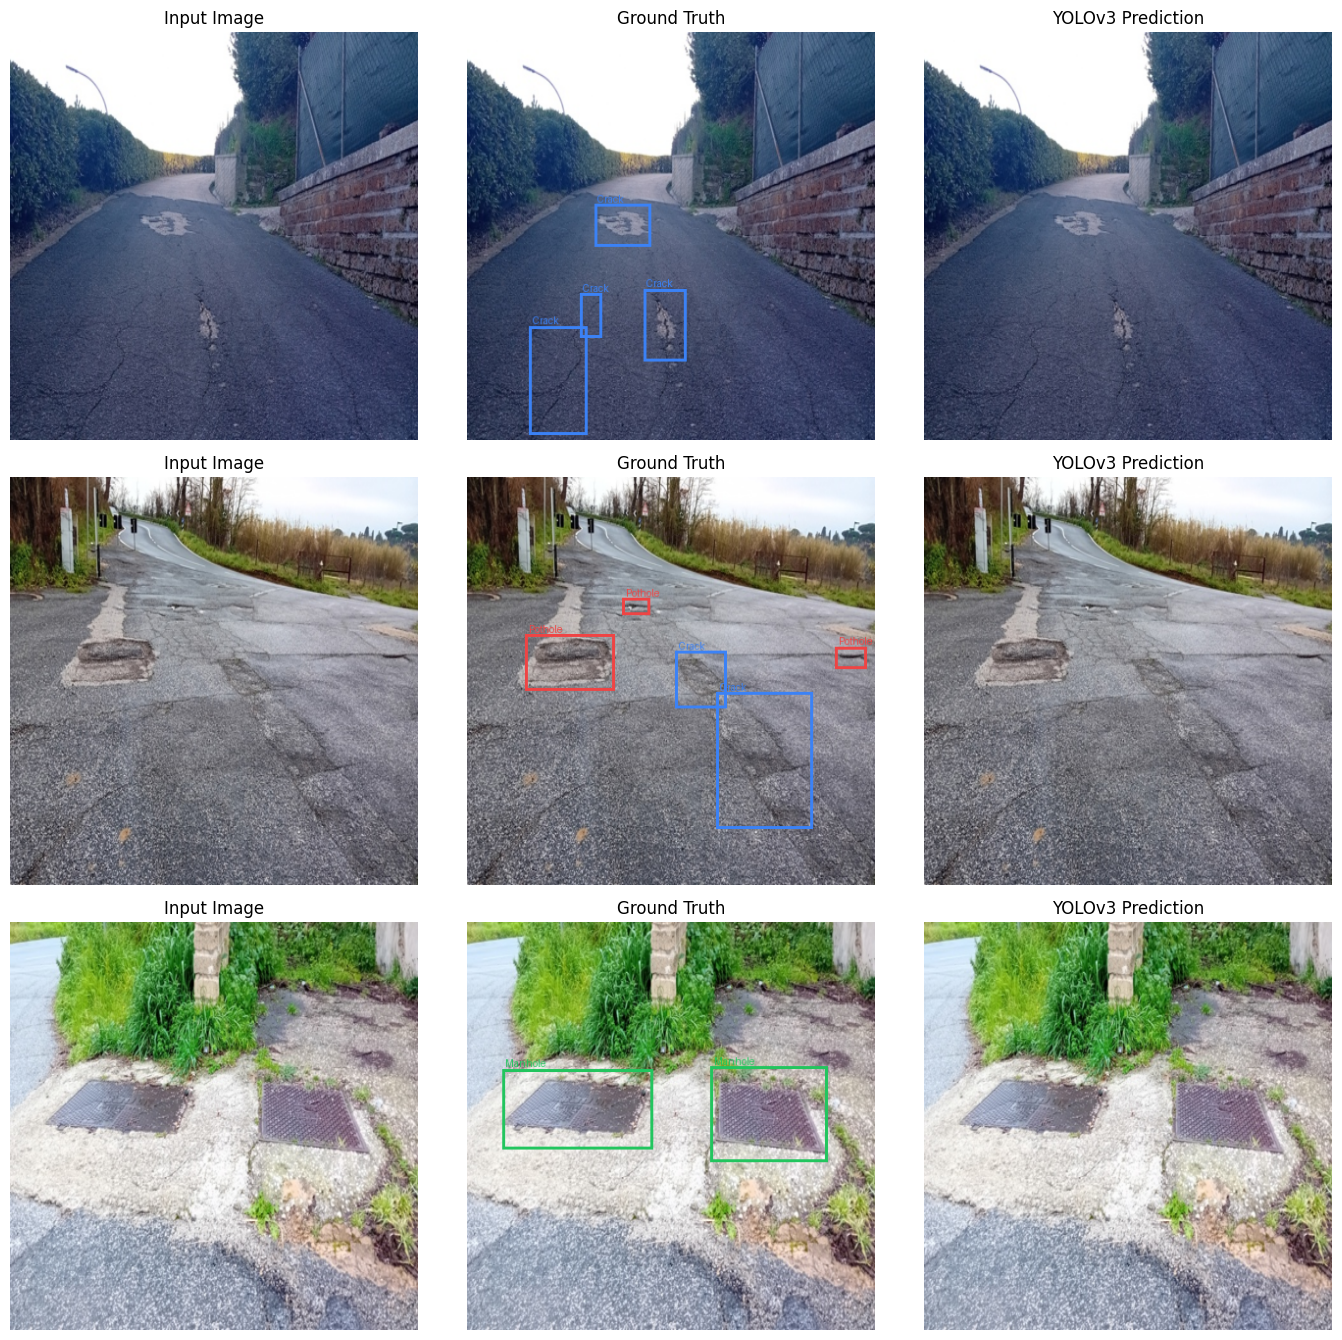

In [16]:
# =========================================================
# TRỰC QUAN HÓA KẾT QUẢ INFERENCE
# =========================================================
@torch.no_grad()
def visualize_predictions(model, dataset, count=3, conf_thresh=0.25):
    count = min(count, len(dataset))
    fig, axes = plt.subplots(count, 3, figsize=(14, 4.5 * count), squeeze=False)
    for row in range(count):
        image, _, raw_target = dataset[row]
        prediction = predict_batch(
            model, image.unsqueeze(0), conf_thresh=conf_thresh
        )[0]
        gt_boxes = xywhn_to_xyxy(raw_target["boxes"], image.shape[-1])

        axes[row, 0].imshow(TF.to_pil_image(image))
        axes[row, 0].set_title("Input Image")
        axes[row, 1].imshow(draw_boxes(image, gt_boxes, raw_target["labels"]))
        axes[row, 1].set_title("Ground Truth")
        axes[row, 2].imshow(
            draw_boxes(
                image,
                prediction["boxes"].cpu(),
                prediction["labels"].cpu(),
                prediction["scores"].cpu(),
            )
        )
        axes[row, 2].set_title("YOLOv3 Prediction")
        for ax in axes[row]:
            ax.axis("off")
    plt.tight_layout()
    plt.show()


if DATA_AVAILABLE:
    visualize_predictions(model, val_dataset, count=3)